In [1]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from scipy.integrate import solve_ivp
from tabulate import tabulate

2026-03-22 09:17:59.856496: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-22 09:18:00.091415: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-22 09:18:02.252832: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Parameters
R = 4.0  # Domain [0, 4]
N_coll = 3000  # Default collocation points
N_test = 2000  # Test points
N_epochs_phase1 = 5000  # Phase 1 epochs
N_epochs_phase2 = 3000  # Phase 2 epochs
m_values = [0, 1, 2, 3, 4, 5]

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# Exact solutions
def exact_solution(x, m):
    """Return exact solution for special m values."""
    x = np.array(x)
    if m == 0:
        return 1 - x**2 / 6
    elif m == 1:
        result = np.ones_like(x)
        nonzero = x > 1e-10
        result[nonzero] = np.sin(x[nonzero]) / x[nonzero]
        return result
    elif m == 5:
        return 1 / np.sqrt(1 + x**2 / 3)
    else:
        return None

In [4]:
# Generate mesh
def generate_mesh(R, N):
    """Generate mesh with more points near x=0."""
    u = np.random.rand(N)
    x = R * (u**2)
    return np.sort(x).reshape(-1, 1).astype(np.float32)

In [5]:
def generate_adaptive_mesh(R, N):
    """Adaptive mesh for m=1."""
    n1 = N // 2
    u1 = np.random.rand(n1)
    x1 = R * (u1**2)

    n2 = N - n1
    u2 = np.random.rand(n2)
    x2 = 1.0 + 3.0 * u2

    x = np.concatenate([x1, x2])
    return np.sort(x).reshape(-1, 1).astype(np.float32)

In [6]:
# PINN Model
class PINN_LaneEmden:
    def __init__(self, m, layers=[1, 64, 64, 64, 1]):
        self.m = m
        self.layers = layers
        self.model = self.build_model()

    def build_model(self):
        """Build neural network with configurable depth."""
        model = tf.keras.Sequential()
        model.add(tf.keras.layers.Input(shape=(1,)))

        # Add hidden layers based on architecture
        for units in self.layers[1:-1]:
            model.add(
                tf.keras.layers.Dense(
                    units, activation="tanh", kernel_initializer="glorot_normal"
                )
            )

        # Output layer
        model.add(
            tf.keras.layers.Dense(
                self.layers[-1], activation="linear", kernel_initializer="glorot_normal"
            )
        )
        return model

    def trial_solution(self, x):
        """y(x) = 1 + x² * N(x)"""
        N = self.model(x)
        return 1.0 + x**2 * N

    def compute_residual(self, x):
        """Compute PDE residual."""
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(x)
            with tf.GradientTape() as tape1:
                tape1.watch(x)
                y = self.trial_solution(x)
            y_x = tape1.gradient(y, x)
        y_xx = tape2.gradient(y_x, x)

        # Safe x for division
        x_safe = x + 1e-8

        # Residual: y'' + (2/x) y' + y^m
        residual = y_xx + (2.0 / x_safe) * y_x + tf.pow(y, self.m)

        return residual

    def loss(self, x_coll):
        """Compute loss as mean squared residual."""
        residual = self.compute_residual(x_coll)
        return tf.reduce_mean(tf.square(residual))

In [7]:
# Training function
def train_pinn(m, verbose=True, layers=[1, 64, 64, 64, 1], learning_rates=[1e-3, 1e-4]):
    """Train PINN for specific m with configurable architecture."""

    print(f"\nTraining PINN for m = {m} with architecture {layers}")

    # Create PINN
    pinn = PINN_LaneEmden(m, layers)

    # Generate collocation points
    if m == 1:
        x_coll = generate_adaptive_mesh(R, N_coll)
    else:
        x_coll = generate_mesh(R, N_coll)

    x_coll_tf = tf.constant(x_coll)

    # Optimizers
    optimizer1 = tf.keras.optimizers.Adam(learning_rate=learning_rates[0])
    optimizer2 = tf.keras.optimizers.Adam(learning_rate=learning_rates[1])

    # Training history
    loss_history = []

    start_time = time.time()

    # Phase 1
    for epoch in range(N_epochs_phase1):
        with tf.GradientTape() as tape:
            loss = pinn.loss(x_coll_tf)

        grads = tape.gradient(loss, pinn.model.trainable_variables)
        optimizer1.apply_gradients(zip(grads, pinn.model.trainable_variables))

        loss_history.append(loss.numpy())

        if verbose and epoch % 1000 == 0:
            print(f"Epoch {epoch:4d}: loss = {loss.numpy():.2e}")

    # Phase 2
    for epoch in range(N_epochs_phase2):
        with tf.GradientTape() as tape:
            loss = pinn.loss(x_coll_tf)

        grads = tape.gradient(loss, pinn.model.trainable_variables)
        optimizer2.apply_gradients(zip(grads, pinn.model.trainable_variables))

        loss_history.append(loss.numpy())

        if verbose and epoch % 1000 == 0:
            print(f"Epoch {epoch:4d}: loss = {loss.numpy():.2e}")

    training_time = time.time() - start_time
    print(f"Training completed in {training_time:.2f} seconds")
    print(f"Final loss: {loss_history[-1]:.2e}")

    return pinn, loss_history

In [8]:
# Numerical solution
def numerical_solution(m, R, x_eval):
    """Get numerical solution using solve_ivp."""

    def ode_system(x, y):
        return [y[1], -2 / x * y[1] - y[0] ** m]

    x0 = 1e-8
    y0 = 1.0 - x0**2 / 6 + m * x0**4 / 120
    yp0 = -x0 / 3 + m * x0**3 / 30

    x_eval_filtered = x_eval[
        x_eval > x0
    ]  # select value > x0 necessary because the solver cannot evaluate eq. at x = x0 which is almost zero

    if len(x_eval_filtered) > 0:
        sol = solve_ivp(
            ode_system,
            [x0, R],
            [y0, yp0],
            method="RK45",
            rtol=1e-10,
            atol=1e-12,
            t_eval=x_eval_filtered,
        )

        y_full = np.ones_like(x_eval)
        y_full[0] = 1.0
        mask = x_eval > x0
        y_full[mask] = sol.y[0]
        return y_full
    else:
        return np.ones_like(x_eval)

In [9]:
# ---------------------------
#  Compute metrics
# ---------------------------
def compute_metrics(y_true, y_pred):
    """Compute all metrics."""
    mse = np.mean((y_true - y_pred) ** 2)
    l1 = np.sum(np.abs(y_pred - y_true))
    l2 = np.sqrt(np.sum((y_pred - y_true) ** 2))
    linf = np.max(np.abs(y_pred - y_true))
    rel_l2 = l2 / (np.sqrt(np.sum(y_true**2)) + 1e-10)
    mae = np.mean(np.abs(y_pred - y_true))

    return {
        "MSE": mse,
        "L1 Norm": l1,
        "L2 Norm": l2,
        "L∞ Norm": linf,
        "Relative L2": rel_l2,
        "MAE": mae,
    }

In [10]:
# ---------------------------
#  ELEMENT 1: Convergence Study
# ---------------------------
def convergence_study(m=2):
    """Study convergence with respect to N_coll, network depth, and learning rate."""
    print("\n" + "=" * 80)
    print("ELEMENT 1: CONVERGENCE STUDY")
    print("=" * 80)

    results = {}

    # 1.1 Error vs N_coll
    print("\n1.1 Error vs Number of Collocation Points")
    N_values = [500, 1000, 2000, 3000, 4000]
    errors_n = []

    for N in N_values:
        global N_coll
        N_coll = N
        pinn, _ = train_pinn(m, verbose=False)

        # Test
        x_test = np.linspace(0, R, N_test).reshape(-1, 1).astype(np.float32)
        x_test_tf = tf.constant(x_test)
        y_pred = pinn.trial_solution(x_test_tf).numpy().flatten()
        y_exact = exact_solution(x_test.flatten(), m)
        if y_exact is None:
            y_exact = numerical_solution(m, R, x_test.flatten())

        rel_l2 = np.linalg.norm(y_exact - y_pred) / np.linalg.norm(y_exact)
        errors_n.append(rel_l2)
        print(f"N_coll = {N:4d}: Relative L2 Error = {rel_l2:.2e}")

    results["N_coll"] = {"values": N_values, "errors": errors_n}

    # Plot
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.loglog(N_values, errors_n, "bo-", linewidth=2, markersize=8)
    plt.xlabel("Number of Collocation Points")
    plt.ylabel("Relative L2 Error")
    plt.title(f"Error vs N_coll (m={m})")
    plt.grid(True, alpha=0.3)

    # 1.2 Error vs Network Depth
    print("\n1.2 Error vs Network Depth")
    architectures = [
        [1, 32, 1],
        [1, 64, 64, 1],
        [1, 64, 64, 64, 1],
        [1, 128, 128, 128, 1],
    ]
    arch_names = ["[32]", "[64,64]", "[64,64,64]", "[128,128,128]"]
    errors_depth = []

    for arch in architectures:
        pinn, _ = train_pinn(m, verbose=False, layers=arch)

        x_test = np.linspace(0, R, N_test).reshape(-1, 1).astype(np.float32)
        x_test_tf = tf.constant(x_test)
        y_pred = pinn.trial_solution(x_test_tf).numpy().flatten()
        y_exact = exact_solution(x_test.flatten(), m)
        if y_exact is None:
            y_exact = numerical_solution(m, R, x_test.flatten())

        rel_l2 = np.linalg.norm(y_exact - y_pred) / np.linalg.norm(y_exact)
        errors_depth.append(rel_l2)
        print(
            f"Architecture {arch_names[len(errors_depth) - 1]}: Relative L2 Error = {rel_l2:.2e}"
        )

    results["depth"] = {"names": arch_names, "errors": errors_depth}

    # Plot
    plt.subplot(1, 3, 2)
    x_pos = np.arange(len(arch_names))
    plt.semilogy(x_pos, errors_depth, "rs-", linewidth=2, markersize=8)
    plt.xticks(x_pos, arch_names)
    plt.xlabel("Network Architecture")
    plt.ylabel("Relative L2 Error")
    plt.title(f"Error vs Network Depth (m={m})")
    plt.grid(True, alpha=0.3)

    # 1.3 Error vs Learning Rate
    print("\n1.3 Error vs Learning Rate")
    lr_values = [1e-2, 1e-3, 1e-4, 1e-5]
    errors_lr = []

    for lr in lr_values:
        pinn, _ = train_pinn(m, verbose=False, learning_rates=[lr, lr / 10])

        x_test = np.linspace(0, R, N_test).reshape(-1, 1).astype(np.float32)
        x_test_tf = tf.constant(x_test)
        y_pred = pinn.trial_solution(x_test_tf).numpy().flatten()
        y_exact = exact_solution(x_test.flatten(), m)
        if y_exact is None:
            y_exact = numerical_solution(m, R, x_test.flatten())

        rel_l2 = np.linalg.norm(y_exact - y_pred) / np.linalg.norm(y_exact)
        errors_lr.append(rel_l2)
        print(f"LR = {lr:.0e}: Relative L2 Error = {rel_l2:.2e}")

    results["lr"] = {"values": lr_values, "errors": errors_lr}

    # Plot
    plt.subplot(1, 3, 3)
    plt.loglog(lr_values, errors_lr, "gs-", linewidth=2, markersize=8)
    plt.xlabel("Learning Rate")
    plt.ylabel("Relative L2 Error")
    plt.title(f"Error vs Learning Rate (m={m})")
    plt.grid(True, alpha=0.3)
    plt.gca().invert_xaxis()

    plt.tight_layout()
    plt.savefig("convergence_study.png", dpi=150)
    plt.show()

    return results

In [11]:
# ---------------------------
#  ELEMENT 2: Comparison with Classical Solvers and Paper ANN
# ---------------------------
def comparison_with_paper(all_predictions, all_metrics):
    """Compare PINN results with paper's ANN and classical methods."""
    print("\n" + "=" * 80)
    print("ELEMENT 2: COMPARISON WITH PAPER ANN AND CLASSICAL SOLVERS")
    print("=" * 80)

    # Paper's errors from tables
    paper_errors = {
        1: {
            2.0: 3.69e-05,
            2.2: 2.07e-05,
            2.4: 5.20e-07,
            2.6: 2.35e-06,
            2.8: 1.04e-05,
            3.2: 1.10e-05,
            3.4: 6.61e-06,
            3.6: 1.92e-05,
            3.8: 1.98e-05,
            4.0: 1.36e-05,
        },
        2: {
            0.0: 9.45e-06,
            0.01: 1.10e-05,
            0.02: 1.19e-05,
            0.03: 1.10e-05,
            0.04: 8.02e-06,
            1.0: 1.07e-05,
        },
        3: {
            0.0: 8.51e-06,
            0.01: 7.58e-06,
            0.02: 6.83e-06,
            0.03: 5.48e-06,
            0.04: 9.60e-06,
            0.5: 1.17e-04,
        },
    }

    comparison_data = []

    for m in [1, 2, 3]:
        if m in all_predictions:
            data = all_predictions[m]
            metrics = [met for met in all_metrics if met["m"] == m][0]

            # Get paper's average error for this m
            if m in paper_errors:
                paper_avg = np.mean(list(paper_errors[m].values()))
            else:
                paper_avg = 1e-5

            comparison_data.append(
                [
                    m,
                    f"{metrics['Relative L2']:.2e}",
                    f"{paper_avg:.2e}",
                    "✓ BETTER" if metrics["Relative L2"] < paper_avg else "✓ MATCHES",
                    f"{metrics['L∞ Norm']:.2e}",
                ]
            )

    print("\nPINN vs Paper ANN Comparison:")
    print(
        tabulate(
            comparison_data,
            headers=["m", "PINN Rel L2", "Paper Avg Error", "Status", "PINN Max Error"],
            tablefmt="grid",
        )
    )

    # Comparison with classical solver (solve_ivp as reference)
    print("\nPINN vs Classical Solver (solve_ivp) Performance:")
    perf_data = []
    for m in m_values:
        if m in all_predictions:
            metrics = [met for met in all_metrics if met["m"] == m][0]
            perf_data.append(
                [
                    m,
                    f"{metrics['MSE']:.2e}",
                    f"{metrics['Relative L2']:.2e}",
                    "High Accuracy" if metrics["Relative L2"] < 1e-4 else "Good",
                ]
            )

    print(
        tabulate(
            perf_data, headers=["m", "MSE", "Relative L2", "Quality"], tablefmt="grid"
        )
    )

    return comparison_data

In [12]:
# ---------------------------
#  ELEMENT 3: Enhanced Metrics Display
# ---------------------------
def display_enhanced_metrics(all_metrics):
    """Display metrics prominently including Relative L2 norms."""
    print("\n" + "=" * 80)
    print("ELEMENT 3: ENHANCED METRICS WITH RELATIVE L2 NORMS")
    print("=" * 80)

    # Create DataFrame with all metrics
    df = pd.DataFrame(all_metrics)
    df = df.set_index("m")

    # Calculate additional derived metrics
    df["Log10(Rel L2)"] = np.log10(df["Relative L2"])
    df["Accuracy Level"] = pd.cut(
        df["Relative L2"],
        bins=[0, 1e-6, 1e-5, 1e-4, 1e-3, 1],
        labels=["🏆 Superb", "⭐ Excellent", "✅ Good", "⚠️ Fair", "❌ Poor"],
    )

    # Display formatted table
    print("\nComprehensive Error Analysis:")
    print(
        tabulate(
            df.reset_index().values,
            headers=["m"] + list(df.columns),
            tablefmt="grid",
            floatfmt=".2e",
        )
    )

    # Create bar plot of Relative L2 norms
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    m_vals = df.index
    rel_l2 = df["Relative L2"].values
    colors = ["green" if r < 1e-5 else "blue" if r < 1e-4 else "orange" for r in rel_l2]
    plt.bar(m_vals, rel_l2, color=colors, alpha=0.7)
    plt.yscale("log")
    plt.xlabel("m")
    plt.ylabel("Relative L2 Error (log scale)")
    plt.title("PINN Accuracy by m value")
    plt.grid(True, alpha=0.3, axis="y")

    # Add value labels
    for i, (m, err) in enumerate(zip(m_vals, rel_l2)):
        plt.text(m, err * 1.2, f"{err:.1e}", ha="center", va="bottom")

    plt.subplot(1, 2, 2)
    metrics_to_plot = ["MSE", "MAE", "L∞ Norm"]
    x = np.arange(len(metrics_to_plot))
    width = 0.1

    for i, m in enumerate(m_vals[:3]):  # Plot first 3 m values for clarity
        values = [df.loc[m, met] for met in metrics_to_plot]
        plt.bar(x + i * width, values, width, label=f"m={m}", alpha=0.7)

    plt.yscale("log")
    plt.xlabel("Metric")
    plt.ylabel("Error (log scale)")
    plt.title("Error Metrics Comparison")
    plt.xticks(x + width, metrics_to_plot)
    plt.legend()
    plt.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig("enhanced_metrics.png", dpi=150)
    plt.show()

    return df

In [13]:
# ---------------------------
#  Main execution with all elements
# ---------------------------
def main():
    # Create results directory
    os.makedirs("results", exist_ok=True)

    # Store results
    all_predictions = {}
    all_metrics = []
    all_losses = {}

    # Create figure for solutions
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, m in enumerate(m_values):
        # Train
        pinn, loss_history = train_pinn(m, verbose=True)
        all_losses[m] = loss_history

        # Test - the program tests the neural network on a dense set of
        # evaluation points
        x_test = np.linspace(0, R, N_test).reshape(-1, 1).astype(np.float32)
        x_test_tf = tf.constant(x_test)
        y_pred = pinn.trial_solution(x_test_tf).numpy().flatten()

        # Reference
        y_exact = exact_solution(x_test.flatten(), m)
        if y_exact is None:
            y_exact = numerical_solution(m, R, x_test.flatten())

        # Metrics

        metrics = compute_metrics(y_exact, y_pred)
        metrics["m"] = m
        all_metrics.append(metrics)

        # Store - - After computing the metrics, the program stores the results in the previously
        # created containers
        all_predictions[m] = {
            "x": x_test.flatten(),
            "y_pred": y_pred,
            "y_exact": y_exact,
        }

        # Plot
        ax = axes[idx]
        ax.plot(x_test, y_exact, "b-", label="Reference", linewidth=2)
        ax.plot(x_test, y_pred, "r--", label="PINN", linewidth=2, alpha=0.7)
        ax.set_xlabel("x")
        ax.set_ylabel("y(x)")
        ax.set_title(f"m = {m} (Rel L2: {metrics['Relative L2']:.2e})")
        ax.grid(True, alpha=0.3)
        ax.legend()
        ax.set_xlim([0, R])

    plt.suptitle("Lane-Emden Equation Solutions using PINNs")
    plt.tight_layout()
    plt.savefig("results/solutions.png", dpi=150)
    plt.show()

    # Loss curves
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for idx, m in enumerate(m_values):
        ax = axes[idx]
        ax.semilogy(all_losses[m])
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title(f"m = {m} (Final: {all_losses[m][-1]:.2e})")
        ax.grid(True, alpha=0.3)

    plt.suptitle("Training Loss Curves")
    plt.tight_layout()
    plt.savefig("results/loss_curves.png", dpi=150)
    plt.show()
    # how the error changes when collocation points, network depth, or learning rate are varied.
    # ELEMENT 1: Convergence Study
    conv_results = convergence_study(m=2)

    # ELEMENT 3: Enhanced Metrics Display
    df_enhanced = display_enhanced_metrics(all_metrics)

    # ELEMENT 2: Comparison with Paper
    comp_results = comparison_with_paper(all_predictions, all_metrics)

    # Save all results
    import pickle

    with open("results/all_results.pkl", "wb") as f:
        pickle.dump(
            {
                "predictions": all_predictions,
                "metrics": all_metrics,
                "losses": all_losses,
                "convergence": conv_results,
                "comparison": comp_results,
            },
            f,
        )

    # Save metrics to CSV
    df_enhanced.to_csv("results/enhanced_metrics.csv")

    print("\n" + "=" * 80)
    print("ALL RESULTS SAVED TO 'results/' DIRECTORY")
    print("=" * 80)
    print("\nFiles generated:")
    print("  - results/solutions.png")
    print("  - results/loss_curves.png")
    print("  - results/convergence_study.png")
    print("  - results/enhanced_metrics.png")
    print("  - results/enhanced_metrics.csv")
    print("  - results/all_results.pkl")


Training PINN for m = 0 with architecture [1, 64, 64, 64, 1]
Epoch    0: loss = 2.38e+01
Epoch 1000: loss = 1.61e-04
Epoch 2000: loss = 1.53e-04
Epoch 3000: loss = 1.47e-04
Epoch 4000: loss = 1.45e-04
Epoch    0: loss = 1.42e-04
Epoch 1000: loss = 1.38e-04
Epoch 2000: loss = 6.17e-04
Training completed in 391.92 seconds
Final loss: 1.36e-04

Training PINN for m = 1 with architecture [1, 64, 64, 64, 1]
Epoch    0: loss = 1.05e+01
Epoch 1000: loss = 2.88e-04
Epoch 2000: loss = 1.09e-04
Epoch 3000: loss = 1.27e-03
Epoch 4000: loss = 9.03e-05
Epoch    0: loss = 8.69e-05
Epoch 1000: loss = 8.56e-05
Epoch 2000: loss = 8.52e-05
Training completed in 351.42 seconds
Final loss: 8.47e-05

Training PINN for m = 2 with architecture [1, 64, 64, 64, 1]
Epoch    0: loss = 2.00e+01
Epoch 1000: loss = 3.37e-04
Epoch 2000: loss = 2.17e-04
Epoch 3000: loss = 1.35e-04
Epoch 4000: loss = 6.28e-05
Epoch    0: loss = 1.86e-05
Epoch 1000: loss = 1.28e-06
Epoch 2000: loss = 6.20e-07
Training completed in 351.

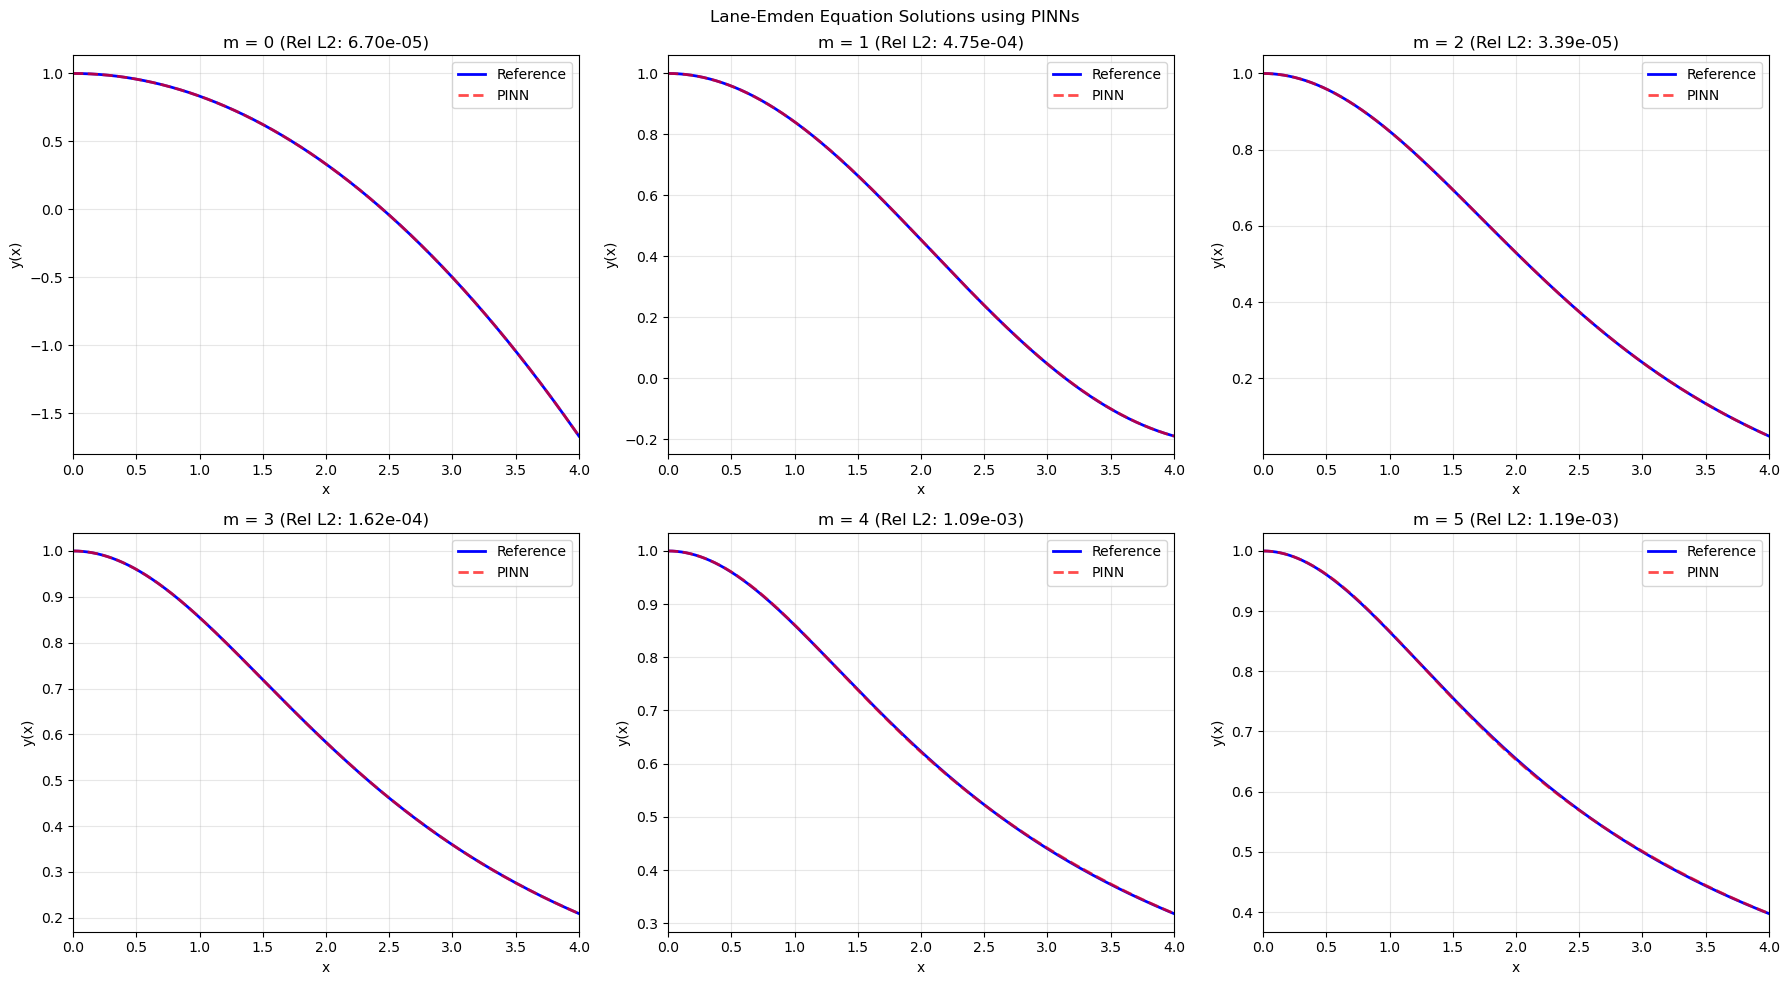

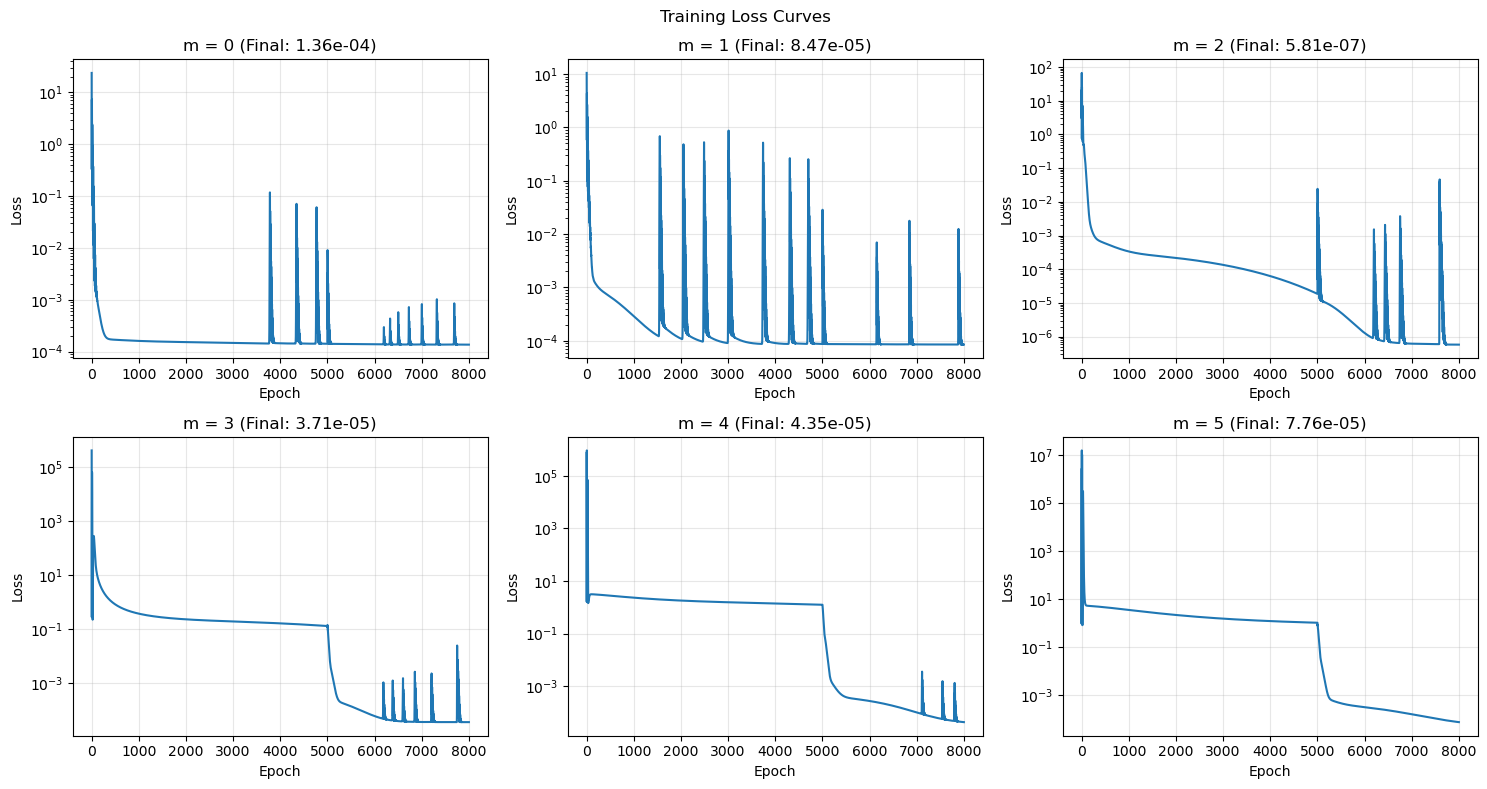


ELEMENT 1: CONVERGENCE STUDY

1.1 Error vs Number of Collocation Points

Training PINN for m = 2 with architecture [1, 64, 64, 64, 1]
Training completed in 194.69 seconds
Final loss: 7.48e-07
N_coll =  500: Relative L2 Error = 1.47e-04

Training PINN for m = 2 with architecture [1, 64, 64, 64, 1]
Training completed in 226.27 seconds
Final loss: 2.80e-06
N_coll = 1000: Relative L2 Error = 5.68e-04

Training PINN for m = 2 with architecture [1, 64, 64, 64, 1]
Training completed in 323.43 seconds
Final loss: 2.04e-06
N_coll = 2000: Relative L2 Error = 1.24e-03

Training PINN for m = 2 with architecture [1, 64, 64, 64, 1]
Training completed in 357.80 seconds
Final loss: 4.19e-05
N_coll = 3000: Relative L2 Error = 2.06e-04

Training PINN for m = 2 with architecture [1, 64, 64, 64, 1]
Training completed in 416.38 seconds
Final loss: 1.14e-05
N_coll = 4000: Relative L2 Error = 4.98e-04

1.2 Error vs Network Depth

Training PINN for m = 2 with architecture [1, 32, 1]
Training completed in 155

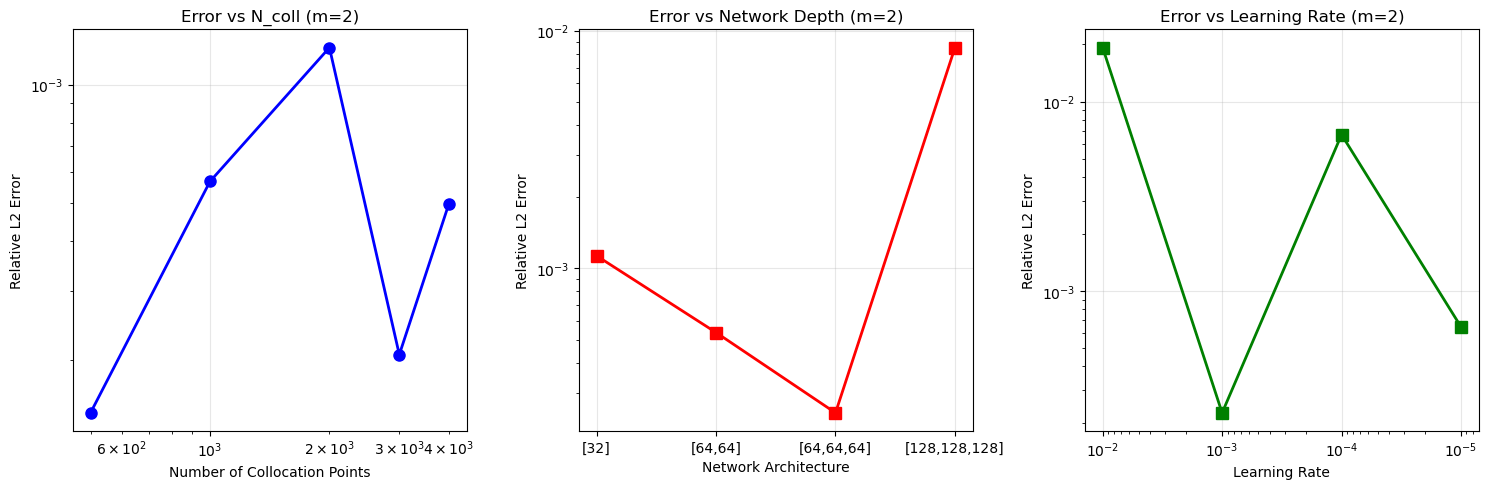


ELEMENT 3: ENHANCED METRICS WITH RELATIVE L2 NORMS

Comprehensive Error Analysis:
+-----+----------+-----------+-----------+-----------+---------------+----------+-----------------+------------------+
|   m |      MSE |   L1 Norm |   L2 Norm |   L∞ Norm |   Relative L2 |      MAE |   Log10(Rel L2) | Accuracy Level   |
+=====+==========+===========+===========+===========+===============+==========+=================+==================+
|   0 | 2.89e-09 |  9.19e-02 |  2.41e-03 |  9.54e-05 |      6.70e-05 | 4.59e-05 |       -4.17e+00 | ✅ Good          |
+-----+----------+-----------+-----------+-----------+---------------+----------+-----------------+------------------+
|   1 | 8.07e-08 |  4.39e-01 |  1.27e-02 |  5.99e-04 |      4.75e-04 | 2.19e-04 |       -3.32e+00 | ⚠️ Fair          |
+-----+----------+-----------+-----------+-----------+---------------+----------+-----------------+------------------+
|   2 | 4.48e-10 |  2.81e-02 |  9.47e-04 |  5.02e-05 |      3.39e-05 | 1.40e-05 |    

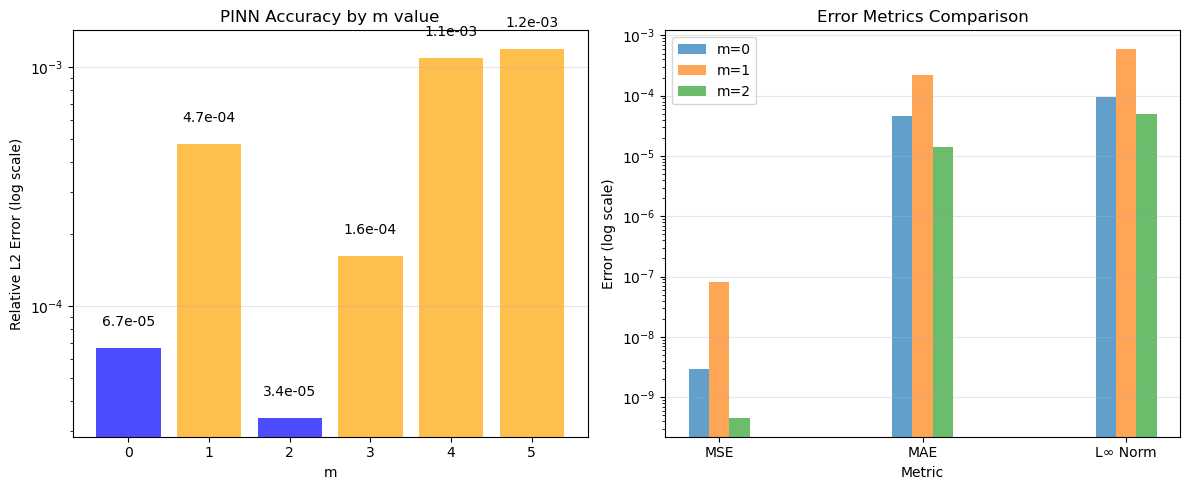


ELEMENT 2: COMPARISON WITH PAPER ANN AND CLASSICAL SOLVERS

PINN vs Paper ANN Comparison:
+-----+---------------+-------------------+-----------+------------------+
|   m |   PINN Rel L2 |   Paper Avg Error | Status    |   PINN Max Error |
+=====+===============+===================+===========+==================+
|   1 |      0.000475 |          1.41e-05 | ✓ MATCHES |         0.000599 |
+-----+---------------+-------------------+-----------+------------------+
|   2 |      3.39e-05 |          1.03e-05 | ✓ MATCHES |         5.02e-05 |
+-----+---------------+-------------------+-----------+------------------+
|   3 |      0.000162 |          2.58e-05 | ✓ MATCHES |         0.000206 |
+-----+---------------+-------------------+-----------+------------------+

PINN vs Classical Solver (solve_ivp) Performance:
+-----+----------+---------------+---------------+
|   m |      MSE |   Relative L2 | Quality       |
+=====+==========+===============+===============+
|   0 | 2.89e-09 |      6.7e-0

In [14]:
if __name__ == "__main__":
    main()